# Example 2 Fashion MNIST classification with PNN and PAT

In this notebook, we show how a physical neural network can be constructed out of coupled nonlinear oscillators to perform the Fashion MNIST task. The main goals of this notebook is to have a self-contained jupyter notebook that walks through the following key steps involved in training a physical neural network via physics aware training.  

- Defining a parametrized input-output map for both the physical and the differentiable digital model
- Constructing the custom autograd function necessary for PAT
- Constructing and training a physical neural network with the custom PAT function at hand
- Load the trained model and visualize the results

For this example, we consider a physical neural network based on coupled nonlinear oscillators. Here we consider all-to-all connected coupled nonlinear oscillators that obeys the following equations of motion. 

$$ \frac{\mathrm{d}^2q_i}{\mathrm{d} t^2} = -\sin{q_i} + \sum_{j=1}^N J_{ij}\left( \sin{q_j} - \sin{q_i} \right) +e_i $$ 
where $q_i$ are the oscillator amplitudes, $J_{ij}$ are the coupling coefficients (which must be symmetric, i.e., $J_{ij}=J_{ji}$), and $e_i$ are individual oscillator drives. For simplicity, we assume that both the coupling and drives are constants (not functions of time $t$).

The oscillator system is turned into a PNN by the following input-output map. We encode the data into the initial amplitudes, and the output is taken to be state of the oscillator after some time-evolution. We choose to set the first derivatives to 0, so the system begins at rest $\dot q_i (t=0) = 0$. Finally, the trainable parameters of the PNN are the coupling constants between the oscillators and the drives, $J_{ij}$, i.e., $\vec{\theta} = [J_{11}, J_{12}, \ldots, J_{NN}, e_1, \ldots e_N]$.

We model the noise present in setting the initial oscillator amplities in an experiment via $q_i(t=0) = x_i + n_i$, where $n_i$ is sampled from a normal distribution of 0.02 standard deviation. Since the initial oscillator amplitude is order unity, this corresponds to about 2\% of noise.

In order to simulate the effect of the mismatch between model and experiment that is addressed by physics-aware training, we add noise to (a) the nonlinearity coefficient, and (b) the coupling coefficients $J_{ij}$. Thus, while the model remains described by the equation above, the physical system is described by:
$$    \frac{\mathrm{d}^2q_i}{\mathrm{d} t^2} = -\sin({(1+\eta)q_i}) + \sum_{j=1}^N (J_{ij}+J^{\mathrm{noise}}_{ij})\left( \sin({(1+\eta)q_j}) - \sin({(1+\eta) q_i}) \right) +e_i $$

Because capturing locality of the image data present in the Fashion MNIST data is important, we consider the following PNN architecture. Here each 28x28 image is divided into 16 patches of 49 pixels each. Each patch is then processed by a **small, 100 oscillator network**. These output are all combined later all concatenated into a 1600 oscillator vector, which is then processed a **larger, 1610 oscillator network**. 

To begin, the notebook will now define the input-output maps associated with both the small and large oscillator networks that are generated from the differential equations above. 

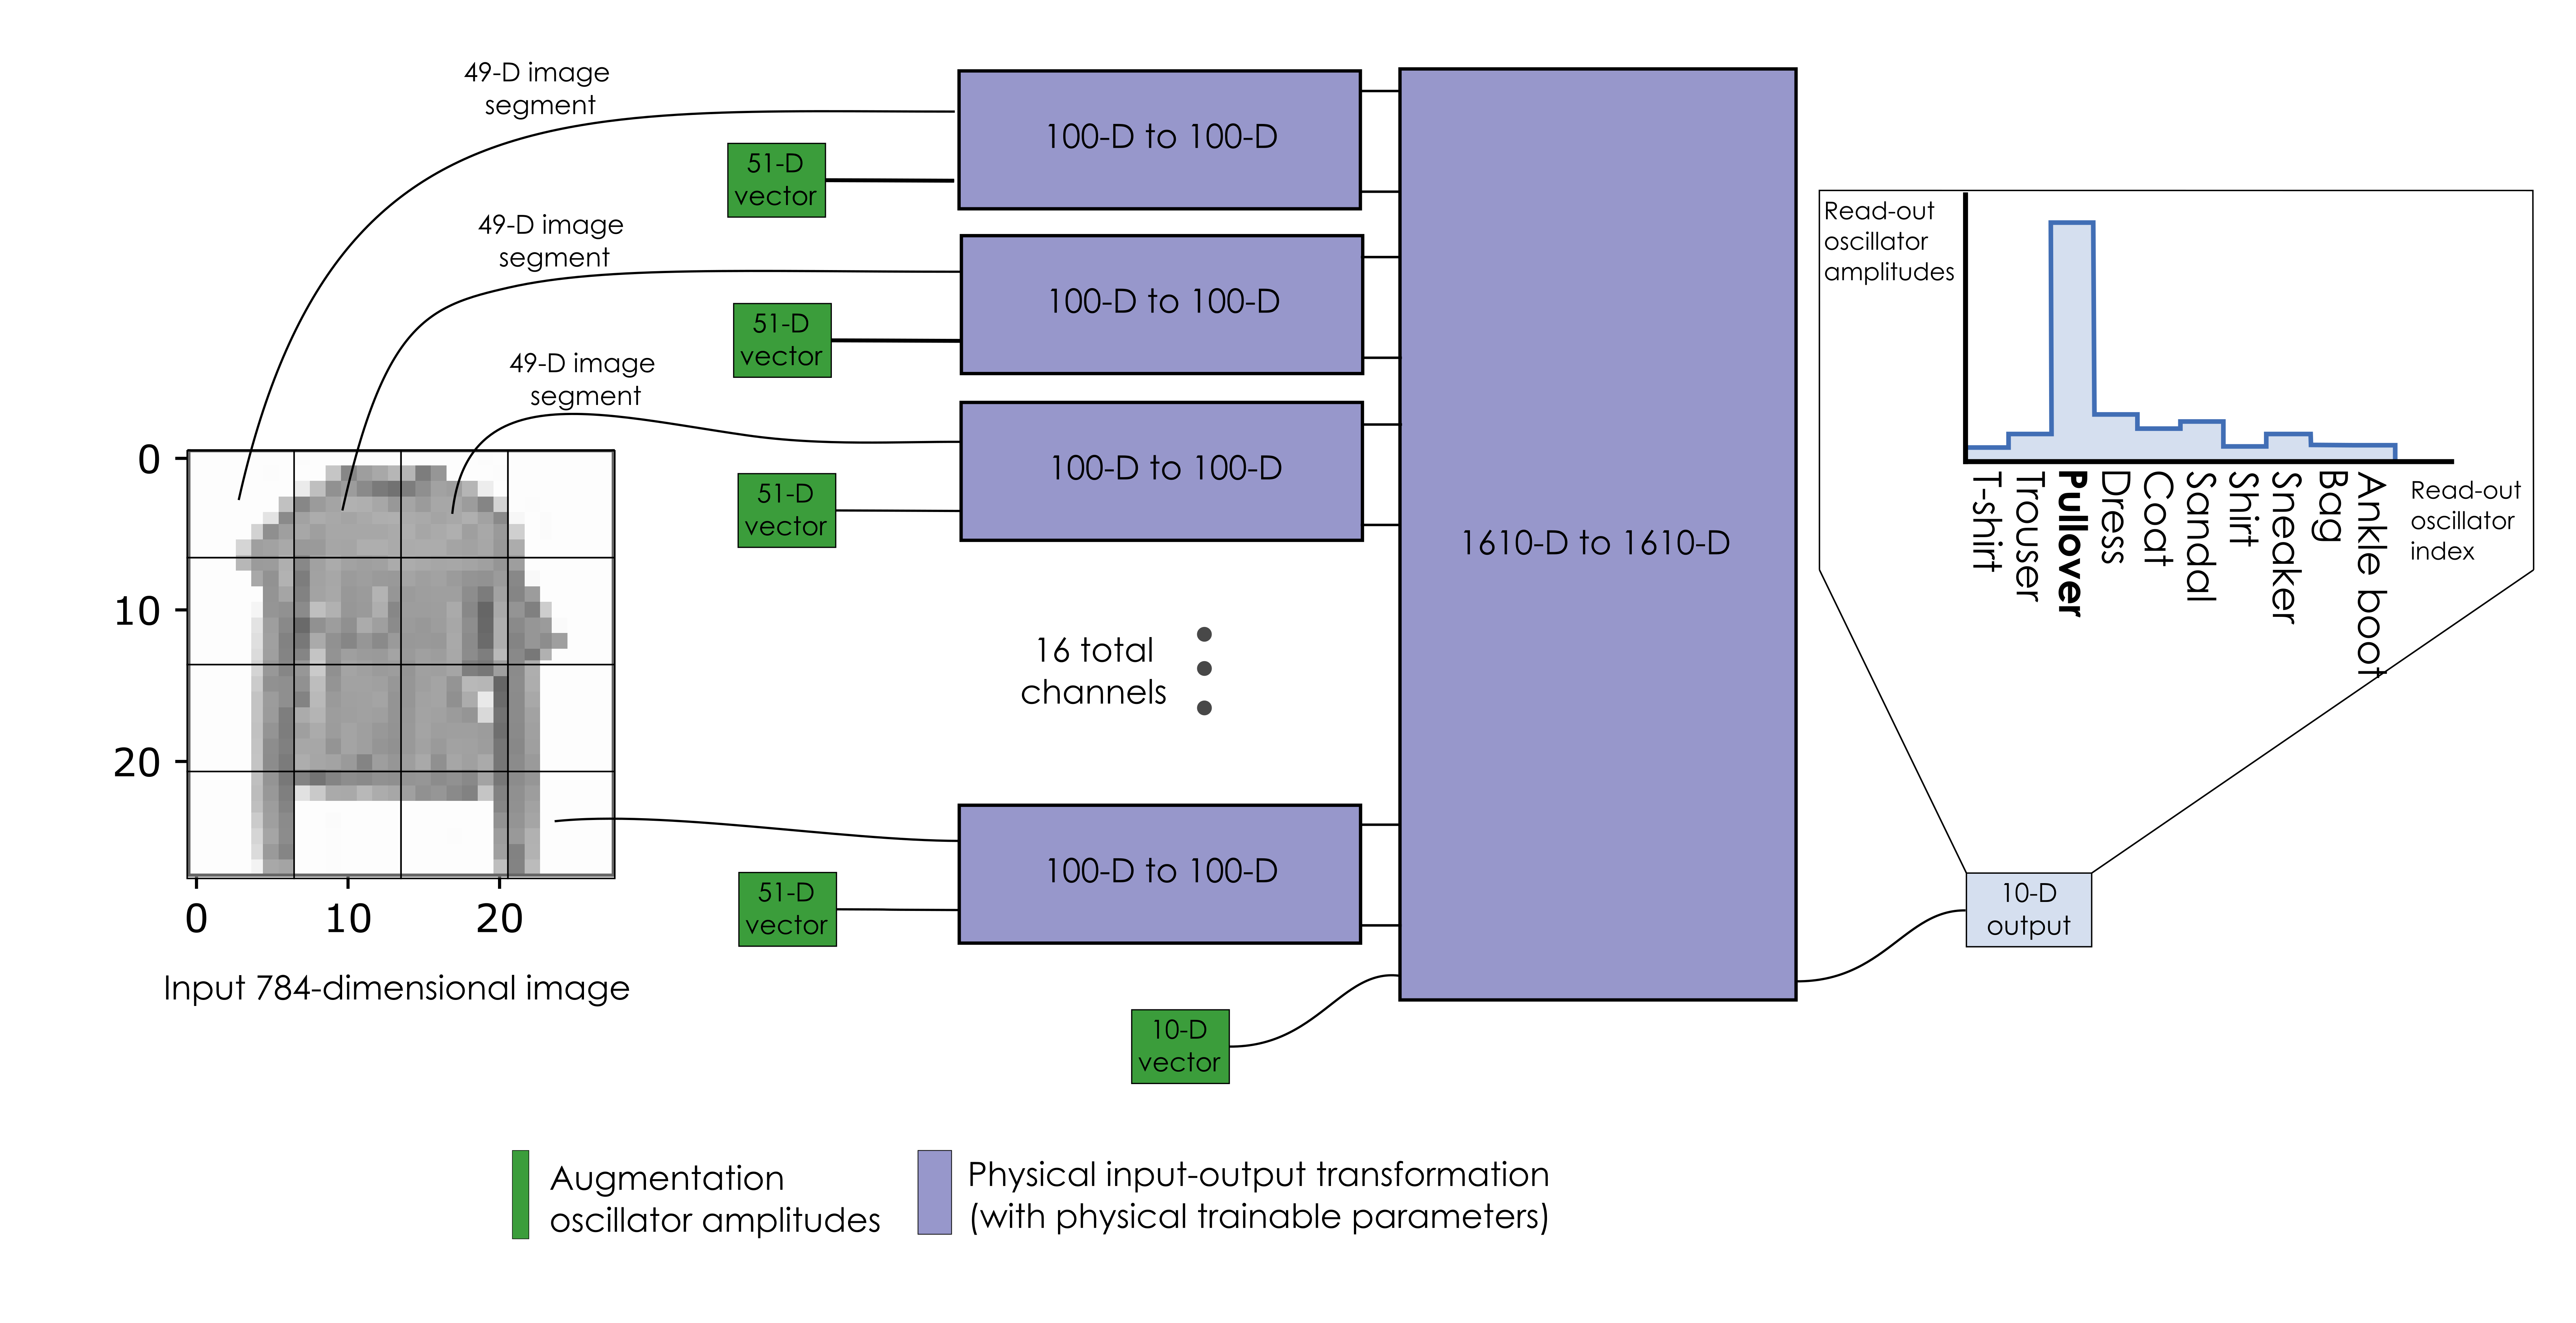

### Parameters of the architecture and simulation

In [1]:
device = "cpu" #use "cpu" if running on CPU, enter the GPU number if running on GPU -- Note: It's important that device is an integer is the GPU case!

#parameters associated with the architecture
image_size = 28
patch_size = 7
dim_small = 100 #dimension of the small oscillator network
num_patches = (image_size // patch_size) ** 2
dim_large = dim_small*num_patches+10 #dimension of the large oscillator network

## Defining the input-output maps

To impose the constraint that the condition that the coupling coefficients $J_{ij}$ is symmetric, we take the following approach of building in this constraint by constructing $J$ from the relation $J = (C + C^\text{T})/2$, where $\text{T}$ is the transpose operation. Here, $C$ is a N by N matrix (that we will generate through the ```nn.Linear``` class), which we can now train without any constraints. 

Finally, for notationally simplicity, we also introduce a new matrix $Q$ such that the offdiagonal elements of $Q$ are that of $J$ and the diagonal elements are given by $Q_{ii} = -\sum_j J_{ij}$. Using this matrix, the equations of motion can be simplified into a matrix multiplication as follows:
$$ \frac{\mathrm{d}^2q_i}{\mathrm{d} t^2} = -\sin{q_i} + \sum_{j=1}^N Q_{ij}\sin{q_j} +e_i $$ 

In [2]:
import torch

#defining an effective J matrix to speed up the computation
def C2Q(C):
    Q = (C + C.T)/2
    C_colsum = -torch.sum(Q, axis=0)
    inds = list(range(C.shape[0]))
    Q[inds, inds] = C_colsum
    return Q

#Define the ODE for the model with this Qmatrix
#Note this ODE can be used as a model for both the small and large oscillator network
def ode_model(z, C, e):
    Q = C2Q(C)
    q = z[..., 0]
    p = z[..., 1]
    output = torch.empty_like(z)
    output[..., 0] = p
    sin_q = torch.sin(q)
    output[..., 1] = -sin_q + e + sin_q@Q
    return output

We emulate the simulation-reality gap, by introducing an additional "noise" coupling matrix $Q_{\text{noise}}$, and by changing the nonlinearity of the network by a factor $\eta$. The ODE for the experiment (forward-pass of the PNN) is given by

$$ \frac{\mathrm{d}^2q_i}{\mathrm{d} t^2} = -\sin[{(1+\eta)q_i}] + e_i + \sum_{j=1}^N Q_{ij}\sin{[(1+\eta)q_j]} + \sum_{j=1}^N Q_{\text{noise},ij}\sin{[(1+\eta)q_j]} $$ 

In [3]:
#parameters associated with noise
J_noise = 0.2
η = 0.1
input_noise = 0.02

#Since the small and large networks require different noise coupling matrix, two separate
#ODE needs to be defined.

torch.manual_seed(0)
# Define the noise coupling matrice for the small network. This is fixed during training and testing. 
Q_noise_small = C2Q(J_noise*torch.randn(dim_small, dim_small)).to(device)

#Define the "experiment" ODE for the small oscillator network
def ode_exp_small(z, C, e):
    Q = C2Q(C)
    q = z[..., 0]
    p = z[..., 1]
    output = torch.empty_like(z)
    output[..., 0] = p
    sin_q = torch.sin((1+η)*q)
    output[..., 1] = -sin_q + e + sin_q@Q + sin_q@Q_noise_small
    return output

# Define the noise coupling matrice for the large network. This is fixed during training and testing. 
Q_noise_large = C2Q(J_noise*torch.randn(dim_large, dim_large)).to(device)

#Define the "experiment" ODE for the large oscillator network
def ode_exp_large(z, C, e):
    Q = C2Q(C)
    q = z[..., 0]
    p = z[..., 1]
    output = torch.empty_like(z)
    output[..., 0] = p
    sin_q = torch.sin((1+η)*q)
    output[..., 1] = -sin_q + e + sin_q@Q + sin_q@Q_noise_large
    return output

#Function to generate the input noise of setting the initial oscillator amplitudes
#Used later when definining the PNN.
def make_noise(x):
    n_tensor = torch.zeros_like(x)
    n_tensor[..., 0] = input_noise*torch.randn(x.shape[:-1])
    return n_tensor

In [4]:
#import functions from utils.py for solving ODEs
from ode_utils import make_ode_map
# make_ode_map is a function that returns the ode_map function, which takes
# in the initial condition x and returns the final state of the ODE after 
# evolving by time Nt*dt. 

#parameters associated with the ODE solver
Nt = 5 #checked that 5 points converges - (same classification accuracy is achieved)
t_end = 0.5 #how long the ODE is time-evolved for
dt = t_end/Nt #discretization step for the ODE solver


#The following 3 blocks of code define the forward and backward functions 
#for a given layer of the PNN. It does this by first generating the 
#ode_map given each corresponding ode.

#The differential digital model for the parameterized input output map of the small oscillator network 
f_model = make_ode_map(ode_model, Nt, dt)

#The parameterized physical input output map of the small oscillator network 
f_exp_small = make_ode_map(ode_exp_small, Nt, dt)

#The parameterized physical input output map of the large oscillator network 
f_exp_large = make_ode_map(ode_exp_large, Nt, dt)

#Function arguments of f_model, f_exp_small, f_exp_large is identical
#It is given by f(x, C, e), 
#where x is the input data, C is the coupling matrix of the network (as used in ode),
#and e is the bias

Given the specification of the physical (forward) functions $f_\text{p}$ and model (backward) function $f_\text{m}$, we can use these to define the physics-aware training custom autograd function $f_\text{PAT}$

In [5]:
from pat import make_pat_func

#this code is used to construct the PAT functions
f_pat_small = make_pat_func(f_exp_small, f_model)
f_pat_large = make_pat_func(f_exp_large, f_model)

## Constructing and training a physical neural network 

### Loading the Fashion MNIST dataset

In [6]:
## Vanilla code for loading the Fashion MNIST dataset
batch_size = 32
from torchvision.datasets import FashionMNIST
from torchvision import transforms
from torch.utils.data.dataloader import DataLoader

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(), 
    transforms.ToTensor()])

transform_val = transforms.Compose([transforms.ToTensor()])

train_set = (FashionMNIST( root = 'ml_dataset', train = True,
            download = True, transform = transform_train ))

val_set = (FashionMNIST( root = 'ml_dataset', train = False,
            download = True, transform = transform_val ))

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=True)

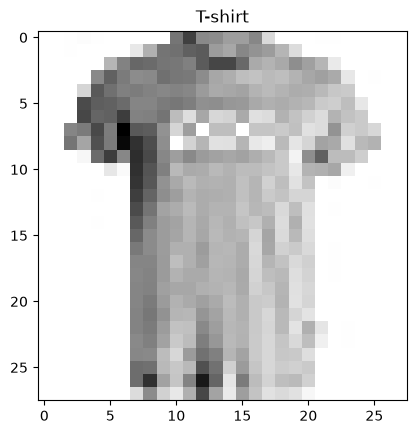

In [7]:
#Visualize one instance of the dataset

import matplotlib.pylab as plt

torch.manual_seed(0)
x, y = next(iter(train_loader))

labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", 
          "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

ind = 3

plt.imshow(x[ind].reshape(28, 28), cmap="binary")
plt.title(labels[y[ind]]);

### Defining the PNN architecture

`PNN` is a plain `torch.nn.Module`. Its forward pass *is* the physics: the data is
loaded into the oscillators as initial amplitudes, the system is evolved, and the
final amplitudes of the ten "class oscillators" are read out as the prediction.

This notebook originally subclassed `pytorch_lightning.LightningModule` and trained
here. That block has been removed: pytorch-lightning 0.9.0 cannot be installed
alongside a current torch, and every Lightning API it called has since been deleted
upstream. The notebook loads the committed checkpoint instead — see the note further
down for the hyperparameters behind it.

To segment the image into patches we use the [einops](https://github.com/arogozhnikov/einops)
package, which allows for complex manipulation of tensors. Any reasonably
up-to-date version works; see `requirements.txt`.

In [8]:
# pytorch-lightning is only required to *train* this model (train_flag = True below).
# This notebook loads precomputed weights, which are plain torch tensors, so we skip it.
# See the git history for the original pl.LightningModule version.

In [9]:
import torch.nn.functional as F
import torch

from einops.layers.torch import Rearrange, Reduce
import torch.nn as nn
import torch.optim as optim

class PNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rearrange = Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)',
                              p1 = patch_size, p2 = patch_size)
        self.fc_small = nn.Linear(dim_small, dim_small)
        self.fc_large = nn.Linear(dim_large, dim_large)
        self.output_fac = nn.Parameter(torch.tensor(1.0).float())

    def forward(self, x):
        #converts the [Nbatch, 1, 28, 28] tensor to the tensor with the 16 patches of 49-dimensional vectors with shape [Nbatch, 16, 49]
        x = self.rearrange(x)

        #augmenting the data vector to include the velocity vector, i.e. dot q = 0
        x = torch.stack([x, torch.zeros_like(x)], dim=-1)
        #augmenting zeros to the patch_size**2 dimensional vector to get a dim_small dimensional vector
        x = torch.cat([x, torch.zeros([*x.shape[:-2], dim_small-patch_size**2, 2]
                                      , device=x.device)], dim=-2)
        #Add noise to the initial condition
        x += make_noise(x)

        #Because of broadcasting, this simple line of code is really running the
        #16 uses of the small oscillator in parallel.
        x = f_pat_small(x, *self.fc_small.parameters())

        #Get the positions of the pendulums
        x = x[..., 0]
        #Flatten the output vector
        x = x.view(x.size(0), -1)

        #Augmenting the data vector to include the velocity vector, i.e. dot q = 0
        x = torch.stack([x, torch.zeros_like(x)], dim=2)
        #Augmenting the initial conditions, which are zeros, of the "class oscillators"
        x = torch.cat([x, torch.zeros([x.shape[0], 10, 2], device=x.device)], dim=1)
        #Add noise to the initial condition
        x += make_noise(x)

        #Use the large oscillator network to obtain a 10-dimensional vector
        x = f_pat_large(x, *self.fc_large.parameters())

        #return the positions of the "class oscillators"
        x = self.output_fac*(x[:, -10:, 0])
        return x

In [10]:
model = PNN().to(device)

#check that the module does successfully run
x, y = next(iter(train_loader))
print(f"output dimensions of PNN is {model(x.to(device)).shape}")

output dimensions of PNN is torch.Size([32, 10])


### Training configuration
The training for this model takes about an hour on a GPU.  Note that the user can interrupt the training and visualize the intermediate results (and rerun at a later time).

If the user wants the skip the training and load the trained model - please skip these cells and run the cells in the next section.

In [11]:
#If train_flag == True -- the following cell of training will run 
#If train_flag == False -- the code will skip the training, and the section below on visualizing the results will load in precomputed results
train_flag = False

if train_flag:
    raise NotImplementedError(
        "The pytorch-lightning training loop was removed so this notebook runs on a "
        "current torch (see git history for the original pl.LightningModule version). "
        "train_flag = True needs a plain-torch training loop first - without one the "
        "cells below silently plot an UNTRAINED model."
    )

In [12]:
log_dir = "training_logs"
if train_flag:
    #defines where the training curve is saved + where the model is saved
    #please feel free to rename the folder and subfolder, that will determine the name of the log
    folder =  "new_results"
    subfolder = "FMNIST_v1"
    
else: 
    folder = "precomputed_results" #load in precomputed results (that was uploaded to github)
    subfolder = "FMNIST"           #FMNIST results
    
import os
data_dir = os.path.join(log_dir, folder, subfolder) #the datadirectory where the data is saved

### How the committed checkpoint was trained

The pytorch-lightning training block used to live here. It has been removed because it
could not be run again: every Lightning API it called has since been deleted
(`gpus=`, `weights_summary=`, `checkpoint_callback=`, `progress_bar_refresh_rate=`,
`pl.TrainResult`, `pl.EvalResult`, `pytorch_lightning.metrics`), and `PNN` is now a
plain `nn.Module` rather than a `LightningModule`. See the git history for the original.

The settings that produced `training_logs/precomputed_results/FMNIST/epoch=17-val_accu=0.90.ckpt`:

| | |
|---|---|
| optimizer | Adam, default learning rate |
| epochs | 20 (best checkpoint at epoch 17) |
| batch size | 32 |
| loss | cross-entropy on the 10 class-oscillator amplitudes |
| checkpoint | best `val_accu`, `mode="max"` |
| logging | CSV to `training_logs/<folder>/<subfolder>/metrics.csv` |

To retrain, write a plain-torch loop - nothing from the old block is reusable.

## Visualize results

In [13]:
import glob
import os
#load the parameters of the model
# data_dir = "precomputed_results/Example3/trial3"

ckpt = glob.glob(os.path.join(data_dir,'*.ckpt'))[0] #it uses glob to find the checkpoint file

if device != "cpu":
    save_dict = torch.load(ckpt, map_location=f"cuda:{device}")
else:
    save_dict = torch.load(ckpt, map_location="cpu")
state_dict = save_dict["state_dict"]
state_dict.keys()

model = PNN().to(device)
model.load_state_dict(state_dict)

<All keys matched successfully>

### Plot the trained coupling matrices and internal dynamics present in the oscillator network

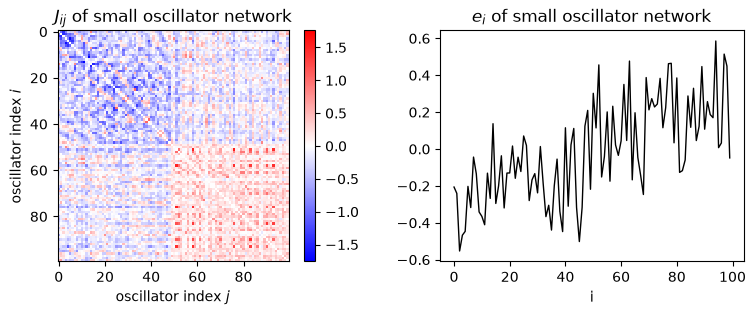

In [14]:
Q_small = C2Q(state_dict["fc_small.weight"])
e_small = state_dict["fc_small.bias"]

J_small = Q_small.clone()

for i in range(J_small.shape[0]):
    J_small[i,i]=0.0

fig, axs = plt.subplots(1, 2, figsize=(9, 3), dpi=100)
fig.subplots_adjust(wspace=0.3)

plt.sca(axs[0])
vmax = torch.max(torch.abs(J_small)).cpu()
plt.imshow((J_small.cpu()), vmax=vmax, vmin=-vmax, cmap="bwr", interpolation="nearest")
plt.colorbar()
plt.ylabel(r"oscillator index $i$")
plt.xlabel(r"oscillator index $j$")
plt.title(r"$J_{ij}$ of small oscillator network")

plt.sca(axs[1])
plt.plot(e_small.cpu(), "k", lw=1)
plt.xlabel("i")
plt.title(r"$e_{i}$ of small oscillator network");

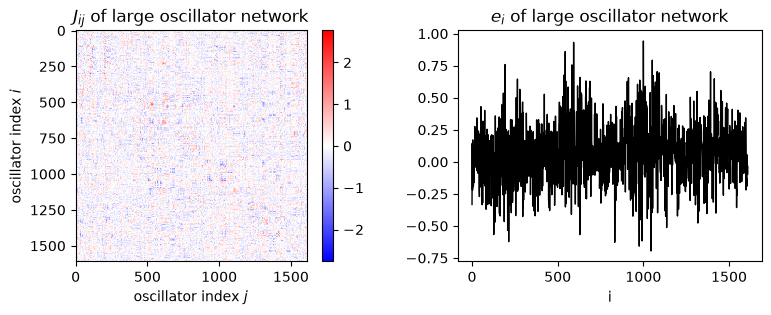

In [15]:
Q_large = C2Q(state_dict["fc_large.weight"])
e_large = state_dict["fc_large.bias"]

J_large = Q_large.clone()

for i in range(J_large.shape[0]):
    J_large[i,i]=0.0

fig, axs = plt.subplots(1, 2, figsize=(9, 3), dpi=100)

fig.subplots_adjust(wspace=0.3)

plt.sca(axs[0])
vmax = torch.max(torch.abs(J_large)).cpu()
plt.imshow((J_large).cpu(), vmax=vmax, vmin=-vmax, cmap="bwr", interpolation="nearest")
plt.colorbar()
plt.ylabel(r"oscillator index $i$")
plt.xlabel(r"oscillator index $j$")
plt.title(r"$J_{ij}$ of large oscillator network")

plt.sca(axs[1])
plt.plot(e_large.cpu(), "k", lw=1)
plt.xlabel("i")
plt.title(r"$e_{i}$ of large oscillator network");

0 T-shirt


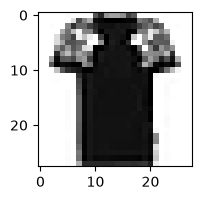

In [16]:
from ode_utils import ode_map_all_points
#ode_map_all_points solves an ODE and also returns the 
#intermediate state vectors during the ODE evolution.
#This is useful for visualizing the dynamics of the model after training.

#parameters related to how much discretization is used for visualizing the ODE evolution
Nt_visual = 100
dt_visual = t_end/Nt_visual
tlist = torch.linspace(0, t_end, Nt_visual)

import numpy as np
import matplotlib.cm as cm

torch.manual_seed(4)
x, y = next(iter(val_loader))

plt.figure(figsize=(2,2))
ind = 4 #ind chooses the image that is fed into the PNN for visualization
img = x[ind, :].numpy()
target = y[ind].numpy()
print(target, labels[target])

plt.imshow(img[0], cmap="binary");

self = model.to(device)
x = x.to(device)

#converts the [Nbatch, 1, 28, 28] tensor to the tensor with the 16 patches of 49-dimensional vectors with shape [Nbatch, 16, 49]
x = self.rearrange(x)

#augmenting the data vector to include the velocity vector, i.e. dot q = 0
x = torch.stack([x, torch.zeros_like(x)], dim=-1) 
#augmenting zeros to the patch_size**2 dimensional vector to get a dim_small dimensional vector
x = torch.cat([x, torch.zeros([*x.shape[:-2], dim_small-patch_size**2, 2] 
                              , device=x.device)], dim=-2)
#Add noise to the initial condition
x += make_noise(x)

#Because of broadcasting, this simple line of code is really running the 
#16 uses of the small oscillator in parallel.

x = f_pat_small(x, *self.fc_small.parameters())

#Get the positions of the pendulums
x = x[..., 0]
#Flatten the output vector
x = x.view(x.size(0), -1)

#Augmenting the data vector to include the velocity vector, i.e. dot q = 0
x = torch.stack([x, torch.zeros_like(x)], dim=2)
#Augmenting the initial conditions, which are zeros, of the "class oscillators"
x = torch.cat([x, torch.zeros([x.shape[0], 10, 2], device=x.device)], dim=1)
#Add noise to the initial condition
x += make_noise(x)

#Use the large oscillator network to obtain a 10-dimensional vector
xlist = ode_map_all_points(ode_exp_large, x, 
                     Nt_visual, dt_visual, *self.fc_large.parameters())

(0.0, 0.5)

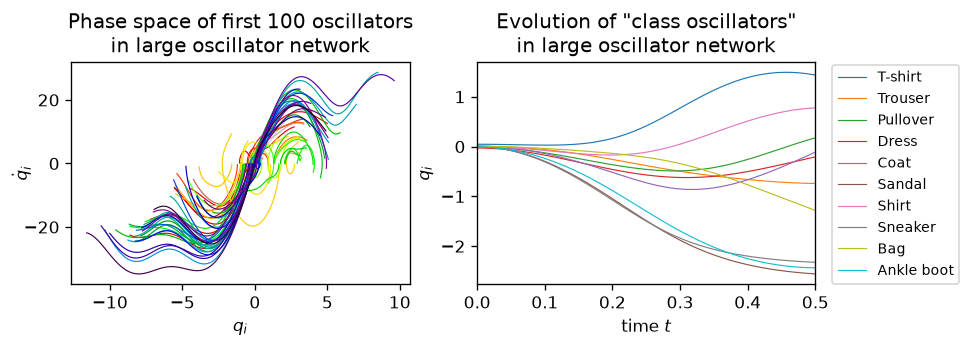

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2.4), dpi=120)

plt.sca(axs[0])
plt.title("Phase space of first 100 oscillators\nin large oscillator network")
for osc_ind in range(100):
    q = [x[ind, osc_ind, 0].cpu().detach() for x in xlist]
    p = [x[ind, osc_ind, 1].cpu().detach() for x in xlist]
    
    plt.plot(q, p, color=cm.nipy_spectral_r(osc_ind/100), lw=0.7)
    plt.ylabel(r"$\dot q_i$", labelpad=-5)
    plt.xlabel(r"$q_i$")
    
plt.sca(axs[1])
plt.title("Evolution of \"class oscillators\"\nin large oscillator network")
for (i, traj) in enumerate(xlist[:, ind, -10:, 0].T):
    plt.plot(tlist, traj.detach().cpu(), color=cm.tab10(i/10), label=f"{labels[i]}", lw=0.7)
plt.legend(loc=(1.05, 0.0), ncol=1, fontsize=8.5)
plt.xlabel(r"time $t$")
plt.ylabel(r"$q_i$")
plt.xlim(0, t_end)

### Plot the training curve and confusion matrix

This requires sci-kit v0.23.1, though in practice, any moderately up-to-date version should work. 

if the user wants to install this version of sklearn run the following code in a cell below (the ```!``` will run a terminal command)

```!pip install scikit-learn==0.23.1```

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import sklearn.metrics as metrics

In [19]:
#the following code runs the trained model on examples from the validation set
#to construct a confusion matrix
torch.manual_seed(0)
x, y = [], []
for xi, yi in list(val_loader):
    x.append(xi)
    y.append(yi)

Nx = 2000
x = torch.cat(x, dim = 0)[:Nx, :].to(device)
target = torch.cat(y, dim = 0)[:Nx]

with torch.no_grad():
    out = model(x)
pred = torch.max(out, 1)[1].cpu()

#the following code makes sure that only 100 example of each class is taken for the confusion matrix
Ndig = 100
target_eq=list()
pred_eq=list()
count = np.zeros(10)
for idx in range(len(pred)):
    ti=target[idx]
    yi=pred[idx]
    count[ti]+=1
    if count[ti]<=Ndig:
        target_eq.append(ti)
        pred_eq.append(yi)
conf = metrics.confusion_matrix(target_eq, pred_eq);

In [20]:
#load the training curve
import pandas as pd
df = pd.read_csv(os.path.join(data_dir, "metrics.csv"))
#Filter out the rows which does not have validation accuracy information with mask
mask = [not(x) for x in np.isnan(df["val_accu"].values)]
epoch = df["epoch"].values[mask]
accu = df["val_accu"].values[mask]

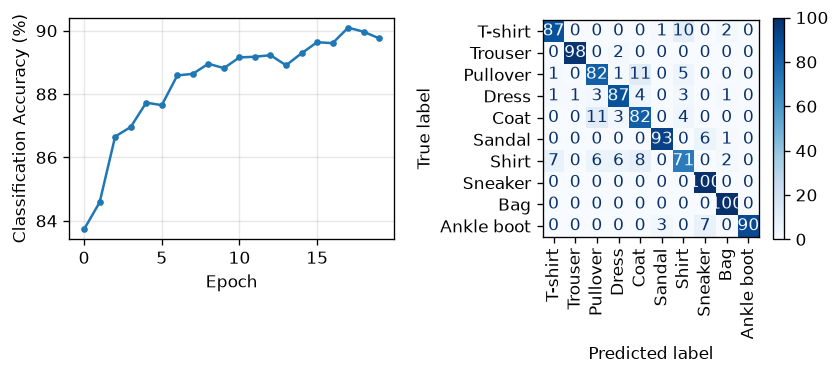

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axs = plt.subplots(1, 2, figsize=(8, 2.4), 
                    gridspec_kw=dict(width_ratios=[0.6, 0.5]), dpi=120)

fig.subplots_adjust(wspace=0.5)
plt.sca(axs[0])
plt.plot(epoch, accu*100, ".-")
plt.grid(alpha=0.3)
plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy (%)")

plt.sca(axs[1])
disp = ConfusionMatrixDisplay(conf, display_labels=labels)
size = 1
disp.plot(cmap=cm.Blues, ax=plt.gca(), values_format="d", xticks_rotation='vertical');

## Part 1: the simulation-reality gap, measured

The network above was trained with PAT, so its parameters are tuned for the *experiment*
(`f_exp_small` / `f_exp_large`) rather than for the *model* (`f_model`). Those are two genuinely
different computers: one has a 10% error in its nonlinearity (`η`) and carries stray couplings
(`Q_noise`) the other knows nothing about.

Here we take the **same trained weights** and run them in both worlds.

In [22]:
import contextlib

#PNN.forward looks up f_pat_small, f_pat_large and make_noise as globals, so we can swap
#the world a network runs in without touching the model or duplicating forward().
@contextlib.contextmanager
def world(fs, fl, noisy):
    global f_pat_small, f_pat_large, make_noise
    saved = (f_pat_small, f_pat_large, make_noise)
    f_pat_small, f_pat_large = fs, fl
    if not noisy:
        make_noise = lambda x: 0   #the model does not know about the input noise either
    try:
        yield
    finally:
        f_pat_small, f_pat_large, make_noise = saved

WORLD_EXP   = dict(fs=f_pat_small, fl=f_pat_large, noisy=True)   #the physical system
WORLD_MODEL = dict(fs=f_model,     fl=f_model,     noisy=False)  #the digital model

In [23]:
#A fixed set of validation images (own variable names, so re-running the
#visualization cells above cannot clobber them)
torch.manual_seed(0)   #so the choice of validation subset is reproducible too
N_eval = 2000
xs, ys = [], []
for xi, yi in val_loader:
    xs.append(xi); ys.append(yi)
    if sum(t.shape[0] for t in xs) >= N_eval:
        break
X_eval = torch.cat(xs)[:N_eval].to(device)
Y_eval = torch.cat(ys)[:N_eval]

def predict(net, w):
    out = []
    net.eval()
    with world(**w), torch.no_grad():
        for i in range(0, X_eval.shape[0], 250):
            out.append(net(X_eval[i:i+250]).argmax(1))
    net.train()
    return torch.cat(out).cpu()

def accuracy(net, w):
    torch.manual_seed(123)   #same input-noise draws for every evaluation
    return (predict(net, w) == Y_eval).float().mean().item()*100

torch.manual_seed(123); pred_exp = predict(model, WORLD_EXP)
torch.manual_seed(123); pred_mod = predict(model, WORLD_MODEL)

accu_exp  = (pred_exp == Y_eval).float().mean().item()*100
accu_mod  = (pred_mod == Y_eval).float().mean().item()*100
agreement = (pred_exp == pred_mod).float().mean().item()*100

print(f"Same trained weights, {N_eval} validation images:")
print(f"  run on the experiment (f_exp_*) : {accu_exp:5.2f}%")
print(f"  run on the model      (f_model) : {accu_mod:5.2f}%")
print(f"  the two agree on                : {agreement:5.2f}% of images")

Same trained weights, 2000 validation images:
  run on the experiment (f_exp_*) : 88.85%
  run on the model      (f_model) : 86.60%
  the two agree on                : 93.35% of images


Text(0.5, 1.0, 'Where they diverge')

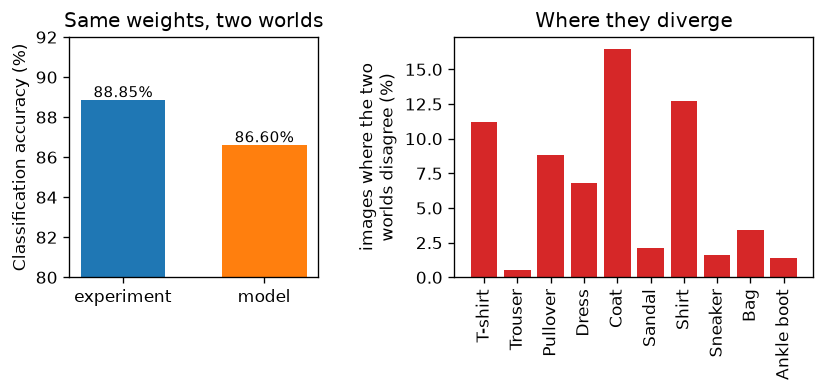

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2.6), dpi=120,
                        gridspec_kw=dict(width_ratios=[0.45, 0.65]))
fig.subplots_adjust(wspace=0.45)

plt.sca(axs[0])
plt.bar(["experiment", "model"], [accu_exp, accu_mod],
        color=["tab:blue", "tab:orange"], width=0.6)
for i, v in enumerate([accu_exp, accu_mod]):
    plt.text(i, v+0.15, f"{v:.2f}%", ha="center", fontsize=9)
plt.ylim(80, 92)
plt.ylabel("Classification accuracy (%)")
plt.title("Same weights, two worlds")

plt.sca(axs[1])
disagree = (pred_exp != pred_mod)
per_class = [100*(disagree & (Y_eval == c)).sum().item() / max((Y_eval == c).sum().item(), 1)
             for c in range(10)]
plt.bar(range(10), per_class, color="tab:red")
plt.xticks(range(10), labels, rotation="vertical")
plt.ylabel("images where the two\nworlds disagree (%)")
plt.title("Where they diverge")

The model and the experiment disagree on a substantial fraction of images even though they are
handed identical parameters and identical inputs. They are not the same computer.

Note also that the PAT-trained weights score *higher* on the experiment than on the model. These
parameters were tuned for one specific device, imperfections included, and moving them elsewhere
costs accuracy.

That establishes the gap exists. It does not yet show that training *through* the gap fails, which
is the actual claim PAT makes. For that we need a second network.

## Part 2: the in-silico counterfactual

The comparison the paper's argument rests on, and which the notebook above never runs: train a
second network **in silico** — using `f_model` for the forward pass *and* the backward pass, so it
never touches the experiment at all — and then deploy it on the experiment.

Both networks get an identical weight initialisation, identical data order, identical optimizer
and an identical epoch budget. The only difference is which function the forward pass ran through.

Set `run_counterfactual = True` to reproduce this (about 16 minutes on a laptop CPU for 3 + 3
epochs). The precomputed results below were produced by exactly the code in this cell.

In [25]:
run_counterfactual = False   #True retrains both networks from scratch (~16 min on CPU)

def train_counterfactual(w, epochs):
    """Train a fresh PNN whose forward pass runs in world `w`, evaluating it in BOTH
    worlds after every epoch. w=WORLD_EXP is PAT; w=WORLD_MODEL is in-silico training."""
    torch.manual_seed(42)                      #identical initialisation for both runs
    net = PNN().to(device)
    opt = optim.Adam(net.parameters())
    loader = DataLoader(train_set, batch_size=32, shuffle=True,
                        generator=torch.Generator().manual_seed(7))   #identical data order
    history = []
    for ep in range(epochs):
        with world(**w):
            for xb, yb in loader:
                loss = F.cross_entropy(net(xb.to(device)), yb.to(device))
                loss.backward(); opt.step(); opt.zero_grad()
        history.append((ep, accuracy(net, WORLD_EXP), accuracy(net, WORLD_MODEL)))
        print(f"  epoch {ep}: experiment {history[-1][1]:5.2f}%  model {history[-1][2]:5.2f}%")
    return history

#(epoch, accuracy on the experiment, accuracy on the model)
counterfactual = {
    "epochs": 3,
    "pat": [
        [
            0,
            85.19999980926514,
            83.45000147819519
        ],
        [
            1,
            86.44999861717224,
            84.54999923706055
        ],
        [
            2,
            87.8000020980835,
            86.54999732971191
        ]
    ],
    "in_silico": [
        [
            0,
            72.75000214576721,
            85.14999747276306
        ],
        [
            1,
            78.89999747276306,
            86.59999966621399
        ],
        [
            2,
            79.25000190734863,
            87.55000233650208
        ]
    ]
}

if run_counterfactual:
    print("PAT:");       counterfactual["pat"]       = train_counterfactual(WORLD_EXP,   counterfactual["epochs"])
    print("in-silico:"); counterfactual["in_silico"] = train_counterfactual(WORLD_MODEL, counterfactual["epochs"])

pat_final, sil_final = counterfactual["pat"][-1], counterfactual["in_silico"][-1]
print(f"\nAfter {counterfactual['epochs']} epochs, evaluated on the EXPERIMENT (deployment):")
print(f"  PAT-trained       : {pat_final[1]:5.2f}%")
print(f"  in-silico-trained : {sil_final[1]:5.2f}%   (it believed it had {sil_final[2]:5.2f}%)")


After 3 epochs, evaluated on the EXPERIMENT (deployment):
  PAT-trained       : 87.80%
  in-silico-trained : 79.25%   (it believed it had 87.55%)


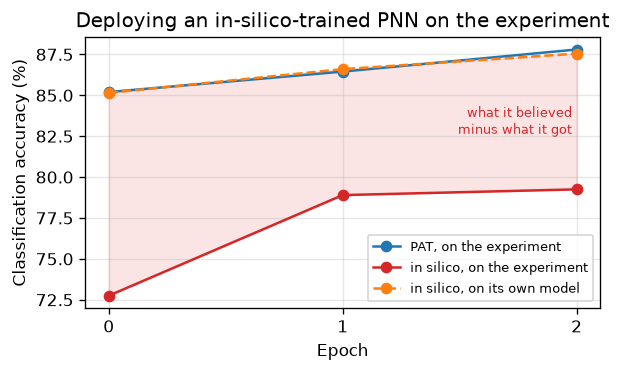

In [26]:
ep_p, exp_p, _     = zip(*counterfactual["pat"])
ep_s, exp_s, mod_s = zip(*counterfactual["in_silico"])

plt.figure(figsize=(5.2, 3.2), dpi=120)
plt.plot(ep_p, exp_p, "o-", color="tab:blue",   label="PAT, on the experiment")
plt.plot(ep_s, exp_s, "o-", color="tab:red",    label="in silico, on the experiment")
plt.plot(ep_s, mod_s, "o--", color="tab:orange", label="in silico, on its own model")
plt.fill_between(ep_s, exp_s, mod_s, color="tab:red", alpha=0.12)
plt.text(ep_s[-1]-0.02, (exp_s[-1]+mod_s[-1])/2, "  what it believed\n  minus what it got",
         fontsize=8, color="tab:red", ha="right", va="center")
plt.xticks(ep_p)
plt.xlabel("Epoch")
plt.ylabel("Classification accuracy (%)")
plt.title("Deploying an in-silico-trained PNN on the experiment")
plt.grid(alpha=0.3)
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()

**The result.** At an equal budget the in-silico network loses roughly eight points of accuracy
the moment it is deployed on the experiment, while the PAT-trained network does not.

Two details in that plot carry the argument:

1. **The in-silico network's self-report is almost exactly PAT's real accuracy.** If you only ever
   looked at your simulator, the two training methods would appear equally good. The entire
   difference is invisible until the hardware is plugged in — you do not get a warning, you get a
   number that looks fine.

2. **The two in-silico curves diverge rather than converge.** Its accuracy on the model keeps
   climbing while its accuracy on the experiment flattens out. It is still learning, just not
   about reality; each further epoch buys fit to the simulator and little else.

This is the same phenomenon as Example 3, where repeated application of a function whose model is
wrong by 0.5% produced a 30% error by the twentieth iteration. Here it is measured in Fashion MNIST
accuracy instead.

**Caveat.** These runs are 3 epochs, not the 20 that produced the committed checkpoint, so the
absolute numbers sit below the notebook's headline 90%. The gap between the two methods is the
quantity of interest, not the endpoints.